In [115]:
from google.colab import drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
import graphviz
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import CategoricalNB


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
dados = pd.read_csv('/content/drive/My Drive/Ciencia_de_dados2/spotify_dataset.csv')
dados

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


Verifica se existe algum valor nulo no conjunto. Como não há valores nulos não precisa eliminar mais nada.

In [118]:
dados.isna().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


4) Calcule a apresente a quantidade de registros em branco e o tipo para cada atributo.


In [119]:
dados.describe(include="all")

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000,8000.000000,8000,8000,8000.000000,8000.000000,8000.000000,8000,8000.000000,8000.000000,8000.000000
unique,NaN,3,NaN,8,4,NaN,NaN,NaN,3,NaN,NaN,NaN
top,NaN,Male,NaN,AU,Premium,NaN,NaN,NaN,Desktop,NaN,NaN,NaN
freq,NaN,2691,NaN,1034,2115,NaN,NaN,NaN,2778,NaN,NaN,NaN
mean,4000.50000,NaN,37.662125,NaN,NaN,154.068250,50.127250,0.300127,NaN,6.943875,0.747750,0.258875
std,2309.54541,NaN,12.740359,NaN,NaN,84.015596,28.449762,0.173594,NaN,13.617953,0.434331,0.438044
min,1.00000,NaN,16.000000,NaN,NaN,10.000000,1.000000,0.000000,NaN,0.000000,0.000000,0.000000
25%,2000.75000,NaN,26.000000,NaN,NaN,81.000000,25.000000,0.150000,NaN,0.000000,0.000000,0.000000
50%,4000.50000,NaN,38.000000,NaN,NaN,154.000000,50.000000,0.300000,NaN,0.000000,1.000000,0.000000
75%,6000.25000,NaN,49.000000,NaN,NaN,227.000000,75.000000,0.450000,NaN,5.000000,1.000000,1.000000


TIPOS

In [ ]:
dados.dtypes

,0
user_id,int64
gender,int64
age,int64
country,int64
subscription_type,int64
listening_time,int64
songs_played_per_day,int64
skip_rate,int64
device_type,int64
ads_listened_per_week,int64


 valores nulos

In [ ]:
nulos = pd.isnull(dados).sum()
print(nulos)

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64


Exclusão da coluna user_id

In [125]:
dados = dados.drop('user_id',axis='columns')

dados depois da exclusao

In [126]:
print("Dataframe criado após a exclusão das colunas")
dados

Dataframe criado após a exclusão das colunas


,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned,gender_Female,gender_Male,gender_Other,...,country_PK,country_UK,country_US,subscription_type_Family,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Desktop,device_type_Mobile,device_type_Web
0,54,26,23,0.20,31,0,1,True,False,False,...,False,False,False,False,True,False,False,True,False,False
1,33,141,62,0.34,0,1,0,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,38,199,38,0.04,0,1,1,False,True,False,...,False,False,False,False,False,True,False,False,True,False
3,22,36,2,0.31,0,1,0,True,False,False,...,False,False,False,False,False,False,True,False,True,False
4,29,250,57,0.36,0,1,1,False,False,True,...,False,False,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,44,237,36,0.30,0,1,1,False,False,True,...,False,False,False,False,False,False,True,False,True,False
7996,34,61,64,0.59,0,1,0,False,True,False,...,False,False,False,False,False,True,False,False,True,False
7997,17,81,62,0.33,5,0,0,True,False,False,...,False,False,True,False,True,False,False,True,False,False
7998,34,245,94,0.27,0,1,0,True,False,False,...,False,False,False,False,False,False,True,True,False,False


Desbalanceamento de classes

In [ ]:
dados['is_churned'].value_counts(normalize=True)


,proportion
is_churned,
0,0.741125
1,0.258875


Representação binária usando a função get_dummies do Pandas.

In [127]:
dados = pd.get_dummies(dados, columns = ['gender','country','subscription_type', 'device_type'])
dados

KeyError: "None of [Index(['gender', 'country', 'subscription_type', 'device_type'], dtype='object')] are in the [columns]"

In [128]:
dados

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned,gender_Female,gender_Male,gender_Other,...,country_PK,country_UK,country_US,subscription_type_Family,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Desktop,device_type_Mobile,device_type_Web
0,54,26,23,0.20,31,0,1,True,False,False,...,False,False,False,False,True,False,False,True,False,False
1,33,141,62,0.34,0,1,0,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,38,199,38,0.04,0,1,1,False,True,False,...,False,False,False,False,False,True,False,False,True,False
3,22,36,2,0.31,0,1,0,True,False,False,...,False,False,False,False,False,False,True,False,True,False
4,29,250,57,0.36,0,1,1,False,False,True,...,False,False,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,44,237,36,0.30,0,1,1,False,False,True,...,False,False,False,False,False,False,True,False,True,False
7996,34,61,64,0.59,0,1,0,False,True,False,...,False,False,False,False,False,True,False,False,True,False
7997,17,81,62,0.33,5,0,0,True,False,False,...,False,False,True,False,True,False,False,True,False,False
7998,34,245,94,0.27,0,1,0,True,False,False,...,False,False,False,False,False,False,True,True,False,False


NORMALIZACAO

In [131]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['age', 'listening_time', 'songs_played_per_day']

scaler = StandardScaler()

dados[cols_to_scale] = scaler.fit_transform(dados[cols_to_scale])

dados[cols_to_scale].head(10)



,age,listening_time,songs_played_per_day
0,1.282452,-1.524434,-0.953574
1,-0.365956,-0.155555,0.417349
2,0.026522,0.534836,-0.426296
3,-1.229408,-1.405401,-1.691763
4,-0.679939,1.141904,0.241590
5,-1.621886,0.772902,-0.531751
6,0.105017,1.606133,-0.215384
7,0.262009,0.665772,0.628261
8,1.360947,-1.238755,0.557957
9,0.497495,1.475196,1.542209


In [132]:
dados

,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned,gender_Female,gender_Male,gender_Other,...,country_PK,country_UK,country_US,subscription_type_Family,subscription_type_Free,subscription_type_Premium,subscription_type_Student,device_type_Desktop,device_type_Mobile,device_type_Web
0,1.282452,-1.524434,-0.953574,0.20,31,0,1,True,False,False,...,False,False,False,False,True,False,False,True,False,False
1,-0.365956,-0.155555,0.417349,0.34,0,1,0,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0.026522,0.534836,-0.426296,0.04,0,1,1,False,True,False,...,False,False,False,False,False,True,False,False,True,False
3,-1.229408,-1.405401,-1.691763,0.31,0,1,0,True,False,False,...,False,False,False,False,False,False,True,False,True,False
4,-0.679939,1.141904,0.241590,0.36,0,1,1,False,False,True,...,False,False,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,0.497495,0.987161,-0.496599,0.30,0,1,1,False,False,True,...,False,False,False,False,False,False,True,False,True,False
7996,-0.287461,-1.107819,0.487653,0.59,0,1,0,False,True,False,...,False,False,False,False,False,True,False,False,True,False
7997,-1.621886,-0.869753,0.417349,0.33,5,0,0,True,False,False,...,False,False,True,False,True,False,False,True,False,False
7998,-0.287461,1.082388,1.542209,0.27,0,1,0,True,False,False,...,False,False,False,False,False,False,True,True,False,False


Transforma os valores qualitativos em codificações numéricas.

In [124]:
#from sklearn.preprocessing import LabelEncoder

#le = LabelEncoder()
#dados['age']=le.fit_transform(dados['age'])
#dados['listening_time']=le.fit_transform(dados['listening_time'])
#dados['skip_rate']=le.fit_transform(dados['skip_rate'])
#dados['device_type']=le.fit_transform(dados['device_type'])
#dados['ads_listened_per_week']=le.fit_transform(dados['ads_listened_per_week'])
#dados['offline_listening']=le.fit_transform(dados['offline_listening'])
#dados['is_churned']=le.fit_transform(dados['is_churned'])
#dados.head(10)

Cria o modelo com todas as variáveis independentes;
Divide os dados em 33% para teste e 67% para treinamento;
Treina o modelo, usando a entropia para escolher os melhores atributos e limita a profundidade máxima da árvore a 3 níveis. Para usar o índice de gini no lugar da entropia basta atribuir gini ao atributo criterion;
Calcula os valores do conjunto de treinamento e as suas medidas de avaliação.
Calcula os valores do conjunto de teste e as suas medidas de avaliação.

In [153]:
X = dados.drop(["is_churned"] ,axis="columns")
y = dados['is_churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=13, shuffle=True)
modelo = DecisionTreeClassifier(criterion='entropy', max_depth=13, random_state=0)
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
print("Relatório do conjunto de treinamento: ")
relatorio_train = classification_report(y_train, y_pred_train)
print(relatorio_train)

y_pred = modelo.predict(X_test)
print("Relatório do conjunto de teste: ")
relatorio_teste = classification_report(y_test, y_pred)
print(relatorio_teste)

Relatório do conjunto de treinamento: 
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      3951
           1       0.85      0.42      0.56      1409

    accuracy                           0.83      5360
   macro avg       0.84      0.70      0.73      5360
weighted avg       0.83      0.83      0.81      5360

Relatório do conjunto de teste: 
              precision    recall  f1-score   support

           0       0.75      0.85      0.79      1978
           1       0.25      0.15      0.19       662

    accuracy                           0.67      2640
   macro avg       0.50      0.50      0.49      2640
weighted avg       0.62      0.67      0.64      2640



matriz de confusão

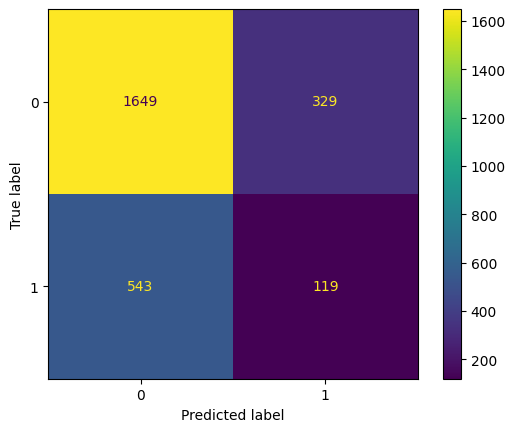

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

matriz = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot()

In [ ]:
dot_data = tree.export_graphviz(modelo, out_file=None,
                              feature_names=X_train.columns,
                              class_names=modelo.classes_.astype(str),
                              filled=True, rounded=True, special_characters=True)

graph = graphviz.Source(dot_data)

graph

In [154]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

X = dados.drop(["is_churned"] ,axis="columns")
y = dados['is_churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=13, shuffle=True)
modelo = RandomForestClassifier(criterion='entropy',max_depth=5)
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
print("Relatório do conjunto de treinamento: ")
relatorio_train = classification_report(y_train, y_pred_train)
print(relatorio_train)

y_pred = modelo.predict(X_test)
print("Relatório do conjunto de teste: ")
relatorio_teste = classification_report(y_test, y_pred)
print(relatorio_teste)


Relatório do conjunto de treinamento: 
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      3951
           1       0.00      0.00      0.00      1409

    accuracy                           0.74      5360
   macro avg       0.37      0.50      0.42      5360
weighted avg       0.54      0.74      0.63      5360

Relatório do conjunto de teste: 
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1978
           1       0.00      0.00      0.00       662

    accuracy                           0.75      2640
   macro avg       0.37      0.50      0.43      2640
weighted avg       0.56      0.75      0.64      2640



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Aplicando SMOTE para balancear o conjunto de dados para o modelo Random Forest.

In [155]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=13)
X_train_res_rf, y_train_res_rf = smote.fit_resample(X_train, y_train)

print('Formato do conjunto de dados original %s' % Counter(y_train))
print('Formato do conjunto de dados reamostrado %s' % Counter(y_train_res_rf))

Formato do conjunto de dados original Counter({0: 3951, 1: 1409})
Formato do conjunto de dados reamostrado Counter({0: 3951, 1: 3951})


Treinando o modelo Random Forest com o conjunto de dados balanceado.

Relatório do conjunto de treinamento (Random Forest balanceado): 
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      3951
           1       0.85      0.79      0.82      3951

    accuracy                           0.83      7902
   macro avg       0.83      0.83      0.83      7902
weighted avg       0.83      0.83      0.83      7902

Relatório do conjunto de teste (Random Forest balanceado): 
              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1978
           1       0.27      0.22      0.24       662

    accuracy                           0.65      2640
   macro avg       0.51      0.51      0.51      2640
weighted avg       0.63      0.65      0.64      2640



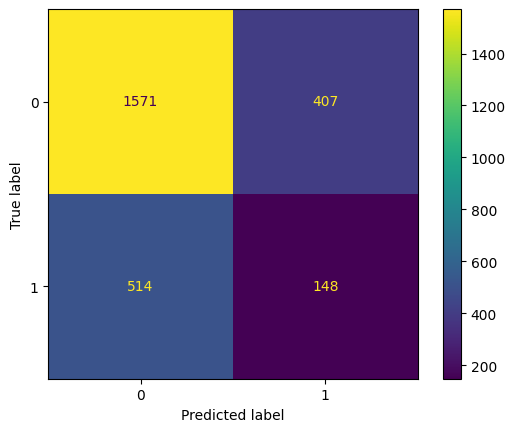

In [156]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Assumindo que X_train_res_rf e y_train_res_rf já foram criados na etapa anterior do SMOTE

modelo_rf_balanced = RandomForestClassifier(criterion='entropy', max_depth=10, random_state=13)
modelo_rf_balanced.fit(X_train_res_rf, y_train_res_rf)

y_pred_train_rf_balanced = modelo_rf_balanced.predict(X_train_res_rf)
print("Relatório do conjunto de treinamento (Random Forest balanceado): ")
relatorio_train_rf_balanced = classification_report(y_train_res_rf, y_pred_train_rf_balanced)
print(relatorio_train_rf_balanced)

y_pred_rf_balanced = modelo_rf_balanced.predict(X_test)
print("Relatório do conjunto de teste (Random Forest balanceado): ")
relatorio_teste_rf_balanced = classification_report(y_test, y_pred_rf_balanced)
print(relatorio_teste_rf_balanced)

matriz_rf_balanced = confusion_matrix(y_test, y_pred_rf_balanced)
disp_rf_balanced = ConfusionMatrixDisplay(confusion_matrix=matriz_rf_balanced)
disp_rf_balanced.plot()

Naive Bayes

Relatório do conjunto de treinamento: 
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      3951
           1       0.31      0.00      0.01      1409

    accuracy                           0.74      5360
   macro avg       0.52      0.50      0.43      5360
weighted avg       0.62      0.74      0.63      5360

Relatório do conjunto de teste: 
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1978
           1       0.00      0.00      0.00       662

    accuracy                           0.75      2640
   macro avg       0.37      0.50      0.43      2640
weighted avg       0.56      0.75      0.64      2640



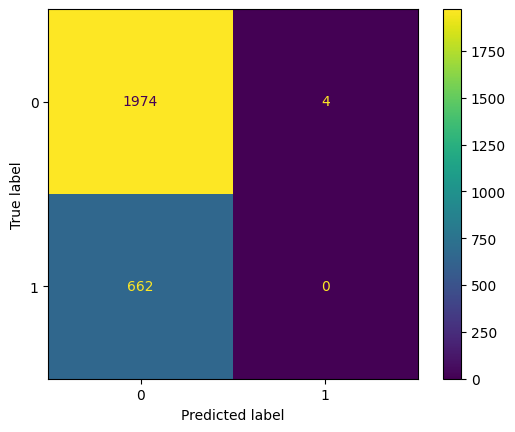

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=13, shuffle=True)
modelo =  GaussianNB() #CategoricalNB()
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
print("Relatório do conjunto de treinamento: ")
relatorio_train = classification_report(y_train, y_pred_train)
print(relatorio_train)

y_pred = modelo.predict(X_test)
print("Relatório do conjunto de teste: ")
relatorio_teste = classification_report(y_test, y_pred)
print(relatorio_teste)

matriz = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot()

Variaveis mais importantes

In [141]:
from sklearn.tree import DecisionTreeRegressor

df4 = dados.copy()
X = df4.drop(['is_churned'] ,axis='columns')
y = df4['is_churned']
modelo = DecisionTreeRegressor(criterion='squared_error', max_depth=7, random_state=42)
modelo.fit(X, y)
print(modelo.feature_names_in_)
print(modelo.feature_importances_)

['age' 'listening_time' 'songs_played_per_day' 'skip_rate'
 'ads_listened_per_week' 'offline_listening' 'gender_Female' 'gender_Male'
 'gender_Other' 'country_AU' 'country_CA' 'country_DE' 'country_FR'
 'country_IN' 'country_PK' 'country_UK' 'country_US'
 'subscription_type_Family' 'subscription_type_Free'
 'subscription_type_Premium' 'subscription_type_Student'
 'device_type_Desktop' 'device_type_Mobile' 'device_type_Web']
[0.13138215 0.2901294  0.14696807 0.20038901 0.04974816 0.
 0.         0.01514933 0.02504359 0.02599823 0.00868682 0.01213061
 0.00566577 0.         0.01165333 0.00705887 0.01988667 0.
 0.005681   0.         0.00916887 0.01587352 0.         0.01938659]


Criacao do modelo

Relatório do conjunto de treinamento: 
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      3951
           1       0.00      0.00      0.00      1409

    accuracy                           0.74      5360
   macro avg       0.37      0.50      0.42      5360
weighted avg       0.54      0.74      0.63      5360

Relatório do conjunto de teste: 
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1978
           1       0.00      0.00      0.00       662

    accuracy                           0.75      2640
   macro avg       0.37      0.50      0.43      2640
weighted avg       0.56      0.75      0.64      2640



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

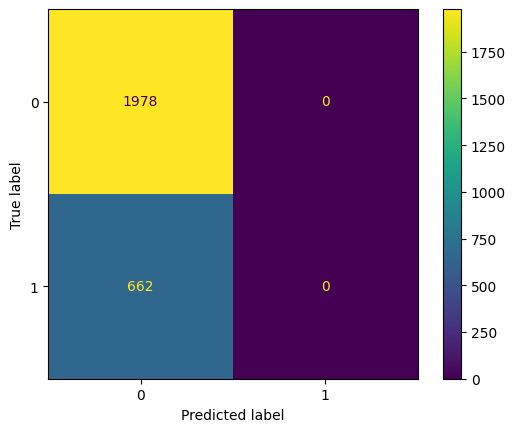

In [149]:
X = dados[['age', 'listening_time', 'songs_played_per_day', 'skip_rate']]
y = dados['is_churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=13, shuffle=True)
modelo = GaussianNB() #CategoricalNB()
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
print("Relatório do conjunto de treinamento: ")
relatorio_train = classification_report(y_train, y_pred_train)
print(relatorio_train)

y_pred = modelo.predict(X_test)
print("Relatório do conjunto de teste: ")
relatorio_teste = classification_report(y_test, y_pred)
print(relatorio_teste)

matriz = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot()

Applying SMOTE to balance the dataset.

In [150]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=13)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Original dataset shape %s' % Counter(y_train))
print('Resampled dataset shape %s' % Counter(y_train_res))

Original dataset shape Counter({0: 3951, 1: 1409})
Resampled dataset shape Counter({0: 3951, 1: 3951})


Training the Naive Bayes model with the balanced dataset.

Relatório do conjunto de treinamento (balanceado): 
              precision    recall  f1-score   support

           0       0.53      0.45      0.48      3951
           1       0.52      0.60      0.56      3951

    accuracy                           0.53      7902
   macro avg       0.53      0.53      0.52      7902
weighted avg       0.53      0.53      0.52      7902

Relatório do conjunto de teste (balanceado): 
              precision    recall  f1-score   support

           0       0.74      0.45      0.56      1978
           1       0.25      0.54      0.34       662

    accuracy                           0.47      2640
   macro avg       0.50      0.49      0.45      2640
weighted avg       0.62      0.47      0.50      2640



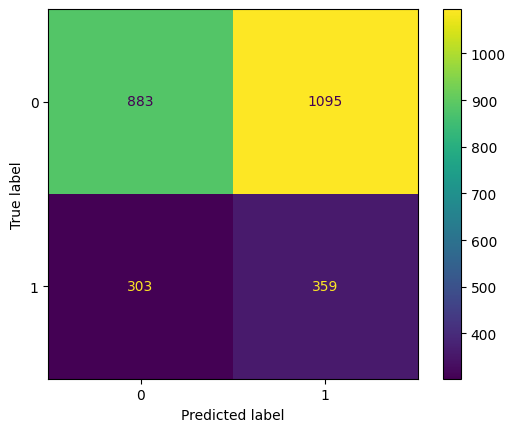

In [151]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Assuming X_train_res and y_train_res are already created from the previous SMOTE step

modelo_balanced = GaussianNB() #CategoricalNB()
modelo_balanced.fit(X_train_res, y_train_res)

y_pred_train_balanced = modelo_balanced.predict(X_train_res)
print("Relatório do conjunto de treinamento (balanceado): ")
relatorio_train_balanced = classification_report(y_train_res, y_pred_train_balanced)
print(relatorio_train_balanced)

y_pred_balanced = modelo_balanced.predict(X_test)
print("Relatório do conjunto de teste (balanceado): ")
relatorio_teste_balanced = classification_report(y_test, y_pred_balanced)
print(relatorio_teste_balanced)

matriz_balanced = confusion_matrix(y_test, y_pred_balanced)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=matriz_balanced)
disp_balanced.plot()